Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Immune"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 87639 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [ ]:
# # Define the category to remove
# excluded_groups = ["27 MY GABA", "10 LSX GABA", "15 HY Gnrh1 Glut"]

# # Filter out the cells belonging to the specified category
# adata = adata[~adata.obs["class"].isin(excluded_groups)].copy()

# print(f"Cells belonging to category '{excluded_groups}' have been removed.")
# adata

Cells belonging to category '['27 MY GABA', '10 LSX GABA', '15 HY Gnrh1 Glut']' have been removed.


AnnData object with n_obs × n_vars = 227667 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [5]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

**Differential Expression**

In [6]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes

In [10]:
# Perform differential expression analysis
group_by="subclass"
sc.tl.rank_genes_groups(
    adata,
    groupby=group_by,
    method="wilcoxon",
    use_raw=False
)

In [11]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# Save the dataframe to a CSV file
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results.to_csv(output_path, index=False)

print(f"Differentially expressed genes saved to {output_path}")

Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Immune-DEG-subclass.csv


## Visualization

In [13]:
deg_results.head()

,334 Microglia NN,335 BAM NN,336 Monocytes NN,337 DC NN,338 Lymphoid NN
0,Cst3,Mrc1,Cd44,Vim,Tmsb10
1,Nav3,Dab2,Lsp1,Crip1,Arhgap15
2,Csmd3,Apoe,Msrb1,Alcam,Skap1
3,Plcl1,F13a1,Gsr,Lsp1,Ablim1
4,Dennd4a,Lyz2,Gda,Iqgap1,Cd52


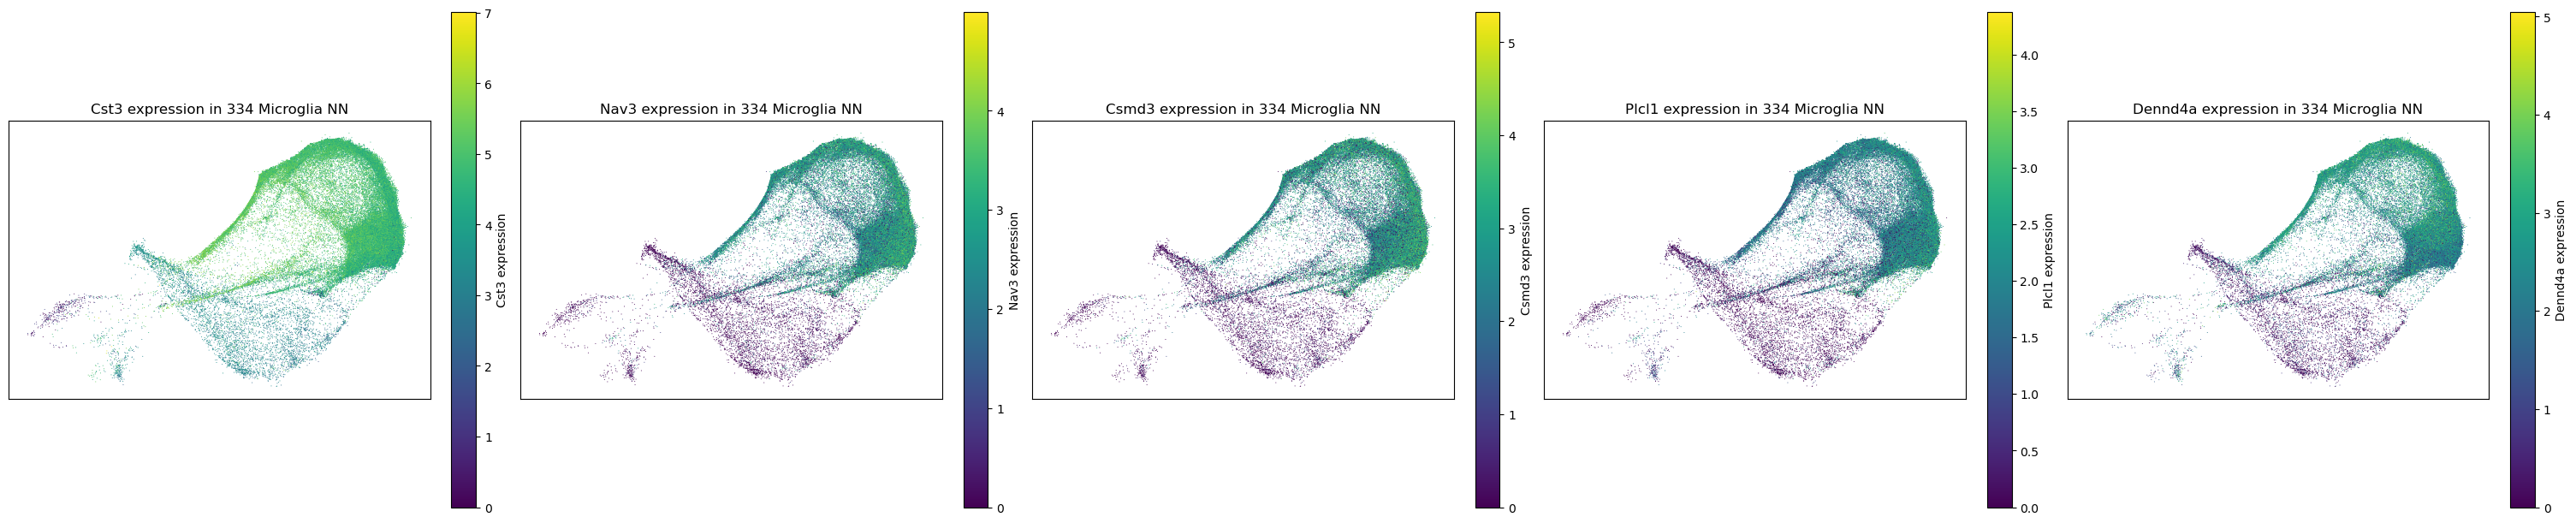

In [14]:
# Select a group and get the top 5 genes
group = "334 Microglia NN"
top_genes = deg_results[group].head(5)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, label=f"{gene} expression")
    ax.set_title(f"{gene} expression in {group}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

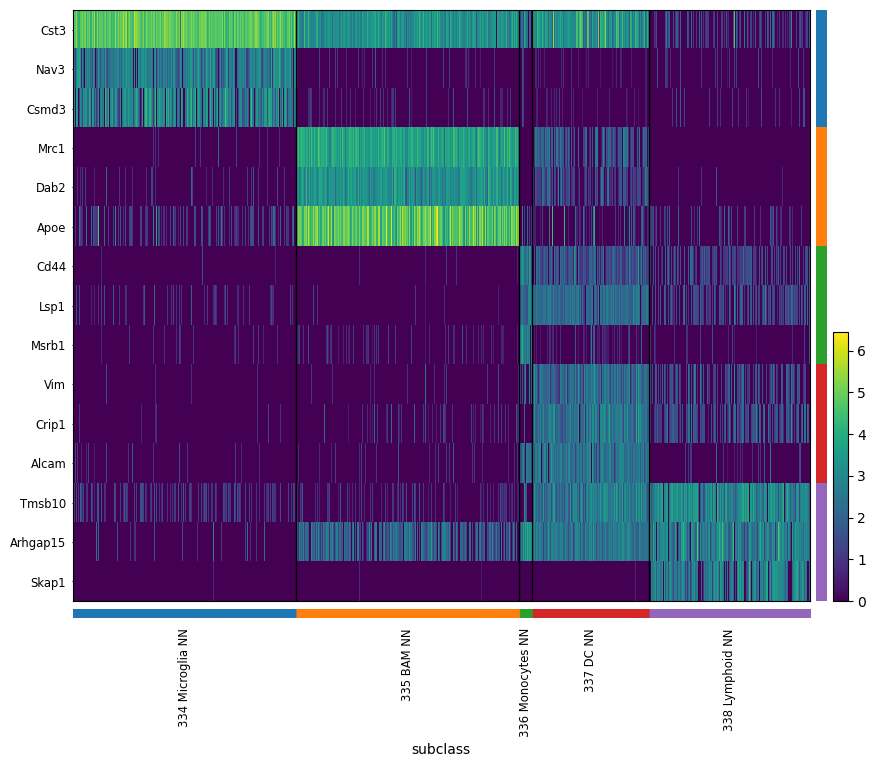

In [28]:
# Define the number of top genes to include per group
n_top_genes = 3

# Extract the top genes for all groups and separate them by group
top_genes_for_heatmap = []
var_group_positions = []
var_group_labels = []
start_idx = 0

for group in deg_results.columns:
    if not deg_results[group].empty:
        group_genes = deg_results[group].dropna().head(n_top_genes).tolist()
        if group_genes:  # Ensure the group has genes
            top_genes_for_heatmap.extend(group_genes)
            var_group_positions.append((start_idx, start_idx + len(group_genes) - 1))
            var_group_labels.append(group)
            start_idx += len(group_genes)

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()

# Compute scaling factors (normalize based on the largest group)
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size  # This replicates your previous calculation

# Store the scaling factors in the AnnData object
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells in large groups to balance the heatmap
max_cells_per_group = 500  # Set a maximum number of cells to display per group

downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
        downsampled_indices.extend(sampled_indices)
    else:
        downsampled_indices.extend(group_indices)

# Ensure correct indexing before subsetting
adata_downsampled = adata[downsampled_indices].copy()

# Adjust the figure size dynamically based on the number of groups and genes
fig_width = max(10, len(var_group_labels) * 2)  # Minimum width of 10, scale with groups
fig_height = max(8, len(top_genes_for_heatmap) * 0.2)  # Minimum height of 8, scale with genes

# Ensure there are genes before plotting
if top_genes_for_heatmap:
    sc.pl.heatmap(
        adata_downsampled,
        var_names=top_genes_for_heatmap,
        groupby=group_by,
        cmap="viridis",
        swap_axes=True,
        figsize=(fig_width, fig_height),
        dendrogram=False,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True
    )
else:
    print("No genes selected for the heatmap.")


## Modules

In [23]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Immune-M1,kME_grey,kME_Immune-M2,kME_Immune-M3,kME_Immune-M4,kME_Immune-M5
ENSMUSG00000024610,ENSMUSG00000024610,Immune-M1,yellow,0.559563,-0.026822,0.087691,0.147090,0.058215,0.275142
ENSMUSG00000060586,ENSMUSG00000060586,Immune-M1,yellow,0.869311,0.001982,0.102990,0.249605,0.082369,-0.016836
ENSMUSG00000036594,ENSMUSG00000036594,Immune-M1,yellow,0.865524,0.001619,0.111349,0.246037,0.085992,-0.018585
ENSMUSG00000073421,ENSMUSG00000073421,Immune-M1,yellow,0.813989,-0.001003,0.087103,0.228217,0.082385,0.008726
ENSMUSG00000044162,ENSMUSG00000044162,Immune-M1,yellow,0.766454,0.003662,0.061605,0.206750,0.063295,0.015329


In [24]:
n_top_genes_per_module = 3  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Immune-M1,kME_grey,kME_Immune-M2,kME_Immune-M3,kME_Immune-M4,kME_Immune-M5
0,ENSMUSG00000060586,Immune-M1,yellow,0.869311,0.001982,0.102990,0.249605,0.082369,-0.016836
1,ENSMUSG00000036594,Immune-M1,yellow,0.865524,0.001619,0.111349,0.246037,0.085992,-0.018585
2,ENSMUSG00000073421,Immune-M1,yellow,0.813989,-0.001003,0.087103,0.228217,0.082385,0.008726
3,ENSMUSG00000039109,Immune-M2,turquoise,0.032909,-0.016909,0.967635,0.004560,0.038460,-0.289491
4,ENSMUSG00000029373,Immune-M2,turquoise,0.019478,-0.025734,0.938860,0.000828,0.044980,-0.270259


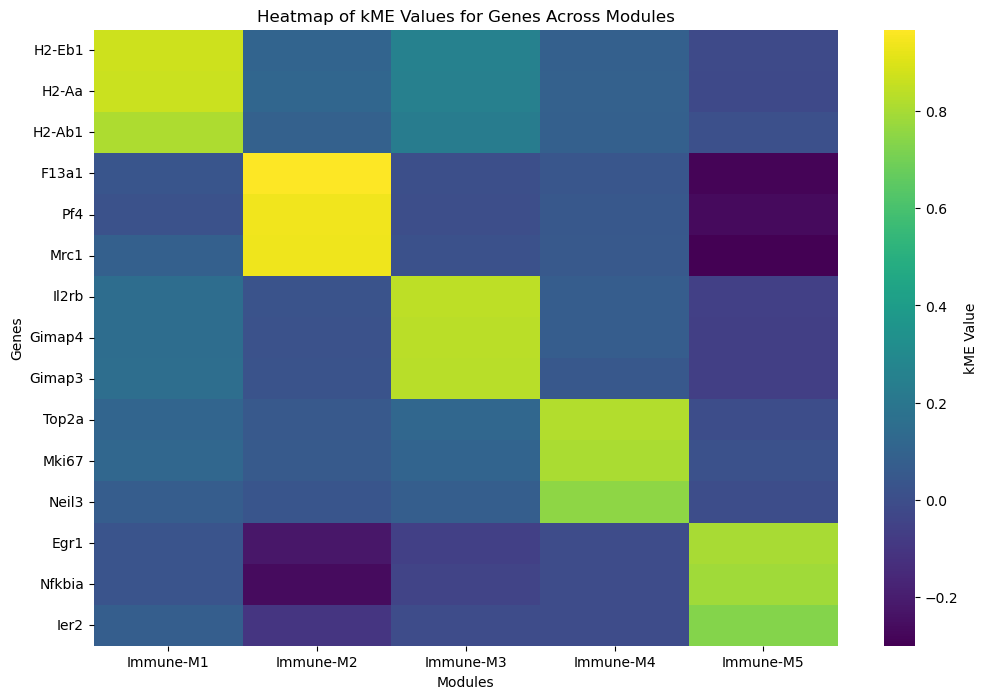

In [ ]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()